# 5.0.3 토이 데이터(Toy Data) 소환과 2D 맵핑 기초

이 노트북은 `pydataset`을 활용하여 장난감 데이터(Toy Data)를 불러오고 시각화하는 실습 과정을 담고 있습니다.

### 💡 VS Code에서 주피터 노트북 실행하는 방법
1. 우측 상단의 **Select Kernel**(커널 선택)을 클릭하고, 설치된 파이썬(Python) 환경을 선택해 주세요.
2. 각 코드 셀 왼쪽의 **▶️ 재생 버튼(Run Cell)**을 클릭하거나, 셀 안에서 **Shift + Enter** 키를 누르면 코드가 실행되고 바로 아래에 결과가 나타납니다.

### 🚨 트러블슈팅: `ModuleNotFoundError` 가 발생할 때

만약 아래 코드들을 실행할 때 `ModuleNotFoundError: No module named 'pydataset'`과 같은 에러가 나타난다면, 이는 현재 노트북을 실행 중인 가상환경(커널)에 실습에 필요한 패키지들이 없기 때문입니다.

> **해결 방법**: 당황하지 마시고, 바로 아래에 있는 코드 셀을 한 번 실행시켜 주세요! 필요한 패키지들이 자동으로 설치됩니다.

In [2]:
# 🚨 처음 실행 시 모듈을 찾을 수 없다는 에러(ModuleNotFoundError)가 발생한다면
# 이 셀을 실행하여 필요한 패키지를 커널에 직접 설치해 주세요.

%pip install pydataset matplotlib seaborn pandas

  Using cached pydataset-0.2.0-py3-none-any.whl
  Using cached matplotlib-3.10.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached

In [3]:
from pydataset import data 

# 함수의 인자를 비워두면, 제공하는 전체 데이터셋 목록표가 DataFrame으로 나옵니다.
all_data = data()
all_data.head()

initiated datasets repo at: /Users/hojin9/.pydataset/


,dataset_id,title
0,AirPassengers,Monthly Airline Passenger Numbers 1949-1960
1,BJsales,Sales Data with Leading Indicator
2,BOD,Biochemical Oxygen Demand
3,Formaldehyde,Determination of Formaldehyde
4,HairEyeColor,Hair and Eye Color of Statistics Students


### [실전 1] `cars` (자동차 제동거리) 데이터 뽑아오기
가장 기초적인 인과관계를 나타내는 `cars` 데이터를 불러와서, `speed`(달리던 속도)와 `dist`(브레이크 밟고 멈출 때까지 미끄러진 제동거리)의 관계를 확인해 보겠습니다.

In [4]:
# 'cars'라는 문자열을 넘기면, 해당 데이터가 2차원 표(DataFrame)로 뽑혀 나옵니다!
cars = data('cars')
cars.head()

,speed,dist
1,4,2
2,4,10
3,7,4
4,7,22
5,8,16


### 차트 도화지(2D 공간)에 표 데이터 매핑(Mapping)하기
이 DataFrame을 `matplotlib`이나 `seaborn`에 넘겨주어 "스피드를 X축(가로)으로 삼고, 미끄러진 거리를 Y축(세로)으로 삼아 교차하는 지점에 점을 찍어줘!" 라고 선언하면 산점도(Scatter Plot)가 그려집니다.

Matplotlib is building the font cache; this may take a moment.


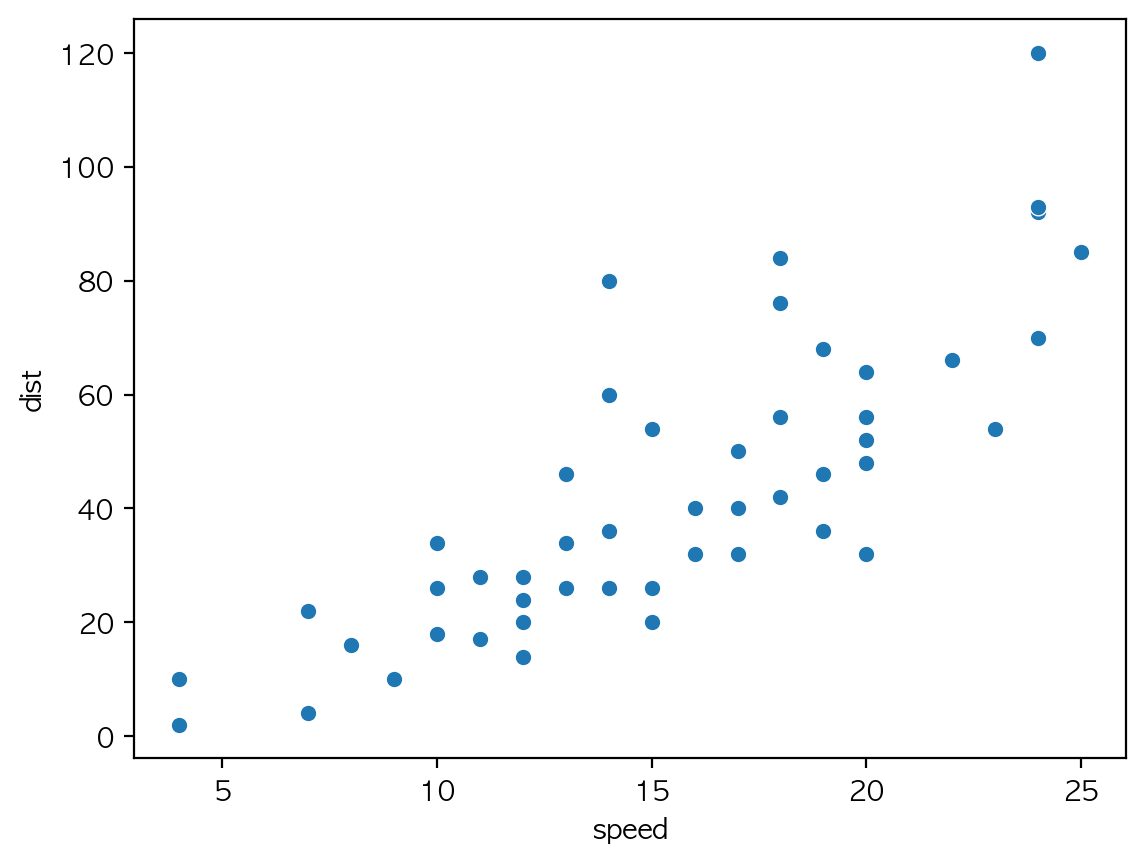

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# [시각화 꿀팁] 주피터 노트북 한글 폰트 & 화질 향상
# Mac 사용자는 'AppleGothic', Windows 사용자는 'Malgun Gothic'을 사용하세요.
plt.rcParams['font.family'] = 'AppleGothic'  
plt.rcParams['axes.unicode_minus'] = False     # 마이너스(-) 기호 깨짐 방지

# 모니터 출력 화질 2배 강화 (주피터 노트북 전용 매직 명령어)
%config InlineBackend.figure_format = 'retina'

# Seaborn 마법 지팡이(템플릿)를 사용하여 점을 찍습니다.
sns.scatterplot(x=cars['speed'], y=cars['dist'])

# 모니터에 지금까지 도화지에 그렸던 그림들을 출력하라!
plt.show() 

### [실전 2] `mpg` (다차원 자동차 연비) 데이터와 군집 시각화
조금 더 속성이 많은 `mpg` 데이터를 꺼내보겠습니다. 단순한 2차원 점 찍기를 넘어 `hue` (색상 매핑)를 사용하여 3번째 차원을 그래프에 입힙니다.

데이터 확인:


,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
1,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
2,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
3,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
4,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
5,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


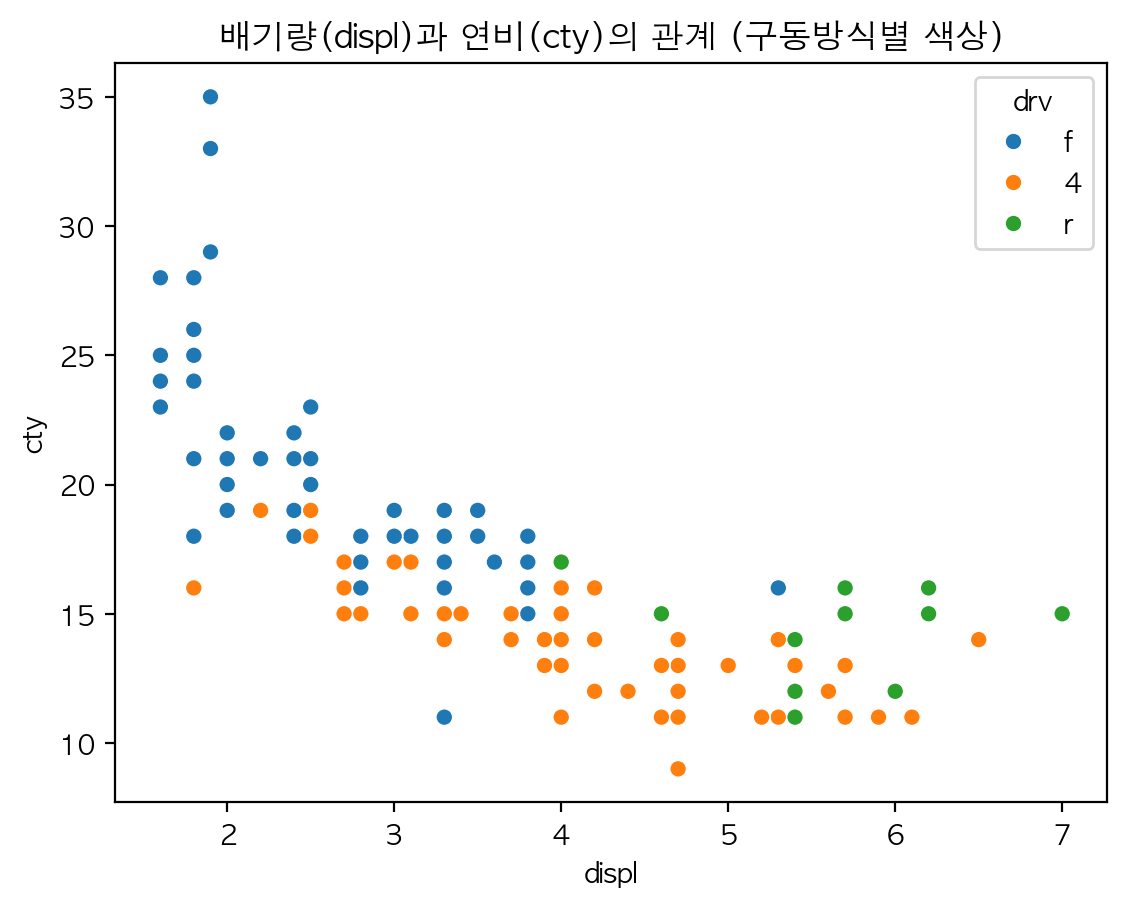

In [6]:
mpg = data('mpg')
print("데이터 확인:")
display(mpg.head())

# hue 옵션에 'drv(구동 방식)' 컬럼을 지정하면, 구동 방식별로 알아서 그룹핑하여 색상을 다르게 칠해줍니다!
sns.scatterplot(data=mpg, x='displ', y='cty', hue='drv')
plt.title("배기량(displ)과 연비(cty)의 관계 (구동방식별 색상)")
plt.show()